In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../original_datasets/delivery_logs.csv')
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 79656 entries, 0 to 79655
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   log_id           79656 non-null  str    
 1   order_id         79656 non-null  str    
 2   event_seq        77229 non-null  float64
 3   event_type       79656 non-null  str    
 4   event_timestamp  78742 non-null  str    
 5   hub_code         79656 non-null  str    
 6   vehicle_id       79656 non-null  str    
 7   scanned_by_emp   79656 non-null  str    
 8   location_city    79656 non-null  str    
 9   remarks          55729 non-null  str    
 10  exception_code   11800 non-null  str    
dtypes: float64(1), str(10)
memory usage: 6.7 MB
None
        log_id    order_id  event_seq    event_type       event_timestamp  \
0  LOG-0002466  ORD-000474        1.0  ORDER_PLACED            1730297579   
1  LOG-0061557  ORD-011734        2.0     PICKED_UP   2025-06-08 01:09:42   
2  LOG-0039779  ORD

In [2]:
print(df.duplicated().sum())

900


In [3]:
df=df.drop_duplicates()

In [ ]:
print(df.isna().sum())

In [4]:
# Convert to uppercase and replace spaces with underscores
df['event_type'] = (
    df['event_type'].astype(str).str.strip().str.upper().str.replace(' ', '_')
)

# Verify unique event types
print(df['event_type'].value_counts())

event_type
ORDER_PLACED        15000
PICKED_UP           15000
DELIVERED           12773
AT_HUB              11295
IN_TRANSIT          11250
OUT_FOR_DELIVERY    11211
FAILED_ATTEMPT       1314
RTO_INITIATED         913
Name: count, dtype: int64


In [5]:
def parse_delivery_timestamp(val):
  if pd.isna(val):
    return np.nan
  val_str = str(val).strip()
  placeholder_vals = ['', 'nan', 'NaN', '-', 'unknown', 'NA', 'N/A', '   ']
  if val_str in placeholder_vals:
    return np.nan

  # Check if Unix epoch timestamp
  if val_str.isdigit():
    try:
      epoch = int(val_str)
      if epoch > 1e11:  # milliseconds
        epoch = epoch / 1000
      dt = pd.to_datetime(epoch, unit='s', errors='coerce')
      if not pd.isna(dt):
        return dt.strftime('%Y-%m-%d %H:%M:%S')
    except:
      pass

  # Try standard datetime formats
  for fmt in (
      '%Y-%m-%d %H:%M:%S',
      '%Y-%m-%dT%H:%M:%SZ',
      '%Y-%m-%dT%H:%M:%S',
      '%Y/%m/%d %H:%M',
      '%Y/%m/%d %H:%M:%S',
      '%d/%m/%Y %H:%M',
      '%d/%m/%Y %H:%M:%S',
      '%d/%m/%Y',
      '%d-%m-%Y',
      '%b %d %Y %I:%M %p',
      '%b %d %Y %H:%M',
      '%B %d %Y %I:%M %p',
      '%Y-%m-%d',
      '%d-%m-%Y %H:%M:%S',
  ):
    try:
      dt = pd.to_datetime(val_str, format=fmt, errors='raise')
      return dt.strftime('%Y-%m-%d %H:%M:%S')
    except ValueError:
      continue

  dt = pd.to_datetime(val_str, errors='coerce')
  if not pd.isna(dt):
    return dt.strftime('%Y-%m-%d %H:%M:%S')
  return np.nan


# Apply timestamp standardization
df['event_timestamp'] = df['event_timestamp'].apply(parse_delivery_timestamp)

In [7]:
print(df['event_timestamp'])
print(df.isna().sum())

0        2024-10-30 14:12:59
1        2025-06-08 01:09:42
2        2024-11-10 09:07:36
3        2025-02-27 01:56:46
4        2024-10-23 02:12:58
                ...         
79649    2024-06-28 19:23:00
79650    2024-04-25 00:06:38
79653    2025-03-17 21:21:26
79654    2024-01-14 12:08:51
79655    2025-02-07 08:00:57
Name: event_timestamp, Length: 78756, dtype: str
log_id                 0
order_id               0
event_seq           2400
event_type             0
event_timestamp     1621
hub_code               0
vehicle_id             0
scanned_by_emp         0
location_city          0
remarks            23677
exception_code     67097
dtype: int64


In [8]:
df['remarks'] = df['remarks'].fillna('None')
df['exception_code'] = df['exception_code'].fillna('None')
df['event_seq'] = df['event_seq'].fillna(df['event_seq'].median())

print("Missing values after filling remarks, exception_code, and event_seq:")
print(df.isnull().sum())

Missing values after filling remarks, exception_code, and event_seq:
log_id                0
order_id              0
event_seq             0
event_type            0
event_timestamp    1621
hub_code              0
vehicle_id            0
scanned_by_emp        0
location_city         0
remarks               0
exception_code        0
dtype: int64


In [10]:
# Save dataset with engineered features
df.to_csv('cleaned_delivery_logs.csv', index=False)

In [ ]:
def check_outliers(series, name):
    valid_series = series.dropna()
    Q1 = valid_series.quantile(0.25)
    Q3 = valid_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = valid_series[(valid_series < lower_bound) | (valid_series > upper_bound)]
    print(f"--- Outlier Analysis for {name} ---")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)} out of {len(valid_series)}\n")

check_outliers(df['event_seq'], 'event_seq')

--- Outlier Analysis for event_seq ---
Q1: 2.0, Q3: 4.0, IQR: 2.0
Lower Bound: -1.0, Upper Bound: 7.0
Number of outliers: 0 out of 78756



C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_17780\1307882984.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index, palette='crest')


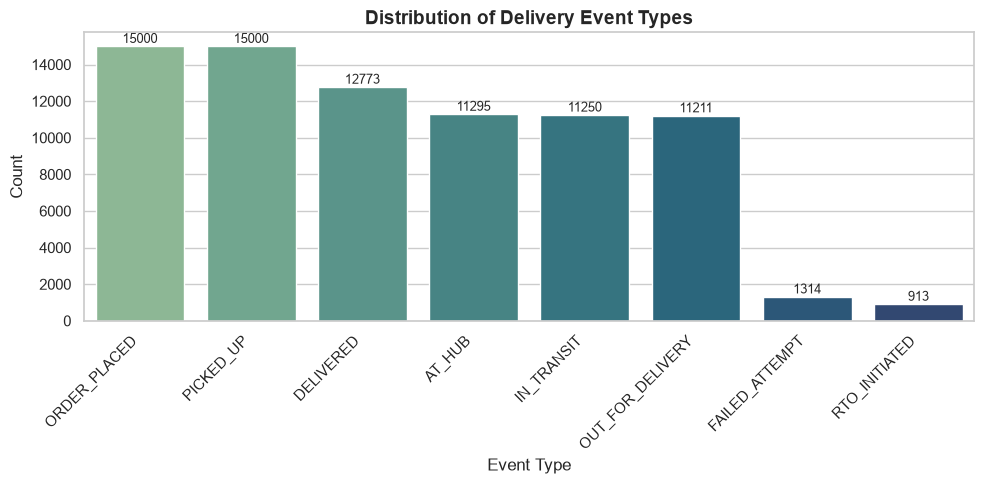

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_17780\1307882984.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='mako')


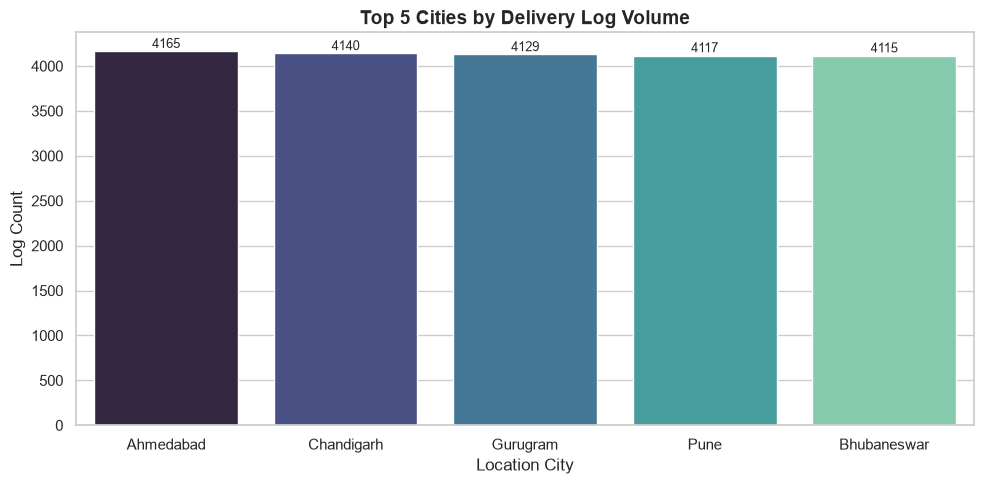

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_17780\1307882984.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_hubs.index, y=top_hubs.values, palette='viridis')


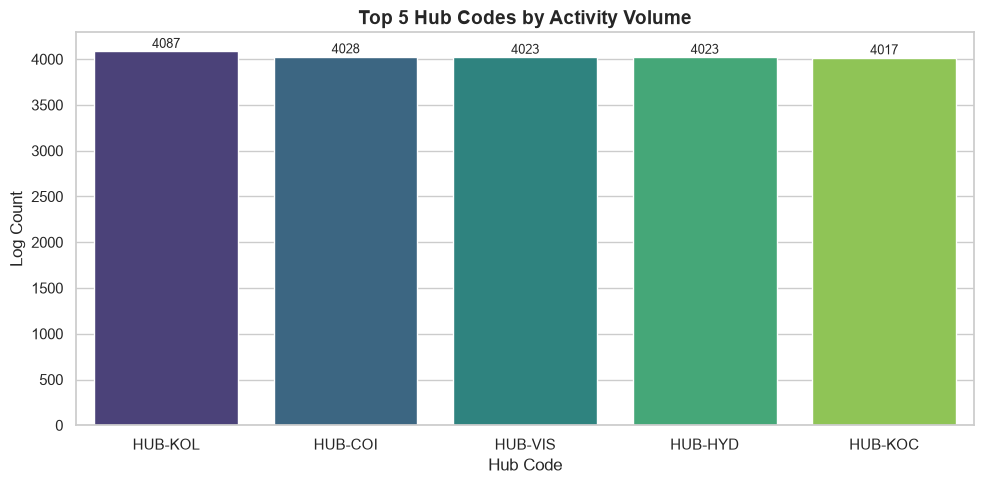

In [ ]:
sns.set_theme(style="whitegrid")
df = pd.read_csv('cleaned_delivery_logs.csv')

# 1. Event Type Distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index, palette='crest')
plt.title('Distribution of Delivery Event Types', fontsize=14, fontweight='bold')
plt.xlabel('Event Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

# 2. Top Cities by Delivery Volume
plt.figure(figsize=(10, 5))
top_cities = df['location_city'].value_counts().head(5)
ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='mako')
plt.title('Top 5 Cities by Delivery Log Volume', fontsize=14, fontweight='bold')
plt.xlabel('Location City', fontsize=12)
plt.ylabel('Log Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

# 3. Top Hubs by Log Count
plt.figure(figsize=(10, 5))
top_hubs = df['hub_code'].value_counts().head(5)
ax = sns.barplot(x=top_hubs.index, y=top_hubs.values, palette='viridis')
plt.title('Top 5 Hub Codes by Activity Volume', fontsize=14, fontweight='bold')
plt.xlabel('Hub Code', fontsize=12)
plt.ylabel('Log Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()
plt.close()
